# Transformer Decoder Block

Implement the decoder side of the Transformer. The decoder adds two things on top of the encoder block: **causal (masked) self-attention** and **cross-attention** to the encoder output. Train on a small sequence-to-sequence task (number sorting) to verify correctness.

## Architecture

Recall the encoder block (Pre-LN):
$$x = x + \text{MHA}(\text{LN}(x))$$
$$x = x + \text{FFN}(\text{LN}(x))$$

The decoder block has **three** sub-layers:

$$x = x + \text{MaskedMHA}(\text{LN}(x))$$
$$x = x + \text{CrossMHA}(\text{LN}(x), \text{encoder\_output})$$
$$x = x + \text{FFN}(\text{LN}(x))$$

**Sub-layer 1: Masked self-attention.** Same as encoder self-attention, but with a causal mask that prevents position $i$ from attending to positions $j > i$. The mask is upper-triangular:

$$M_{ij} = \begin{cases} 1 & \text{if } j \leq i \\ 0 & \text{if } j > i \end{cases}$$

Masked positions are set to $-\infty$ before softmax, so future tokens contribute zero weight.

**Sub-layer 2: Cross-attention.** Queries come from the decoder. Keys and values come from the encoder output. This is how the decoder "reads" the source sequence. No causal mask here, since the decoder should attend to the entire source.

**Sub-layer 3: FFN.** Identical to the encoder FFN.

## Why Causal Masking

During training, the decoder processes the entire target sequence in parallel (teacher forcing). Without a mask, position $i$ would see the ground-truth token at position $i+1$, leaking the answer.

The causal mask enforces the autoregressive property:
$$P(y_t | y_1, \ldots, y_{t-1}, X)$$

At inference time, tokens are generated one at a time, so the mask is implicit (future tokens simply don't exist yet). But during training, the mask is essential for correct learning.

## Cross-Attention Dimensions

Let the source (encoder) sequence have length $n_s$ and the target (decoder) sequence have length $n_t$.

- $Q = X_{\text{dec}} W^Q \in \mathbb{R}^{n_t \times d_k}$ (from decoder)
- $K = X_{\text{enc}} W^K \in \mathbb{R}^{n_s \times d_k}$ (from encoder)
- $V = X_{\text{enc}} W^V \in \mathbb{R}^{n_s \times d_v}$ (from encoder)

Attention scores: $QK^T \in \mathbb{R}^{n_t \times n_s}$

Output: $\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V \in \mathbb{R}^{n_t \times d_v}$

Each decoder position produces a weighted combination of all encoder positions. The weights are learned: the model discovers which source tokens are relevant for predicting each target token.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# --- Reused from previous notebooks ---

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        Q = self.W_q(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        attn_output = self.dropout(attn_output)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(attn_output), attn_weights


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        normed = self.norm1(x)
        attn_output, _ = self.attention(normed, normed, normed, mask)
        x = x + self.dropout(attn_output)
        normed = self.norm2(x)
        ff_output = self.feed_forward(normed)
        x = x + self.dropout(ff_output)
        return x

## Implementation: Decoder Block

In [3]:
class TransformerDecoderBlock(nn.Module):
    """
    Single Transformer decoder block (Pre-LN variant).

    Three sub-layers:
        1. Masked self-attention (causal)
        2. Cross-attention (queries from decoder, keys/values from encoder)
        3. Feed-forward network

    Each sub-layer: LayerNorm -> sub-layer -> dropout -> residual add.

    Args:
        d_model: model dimension
        n_heads: number of attention heads
        d_ff: feed-forward hidden dimension
        dropout: dropout rate
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        # Sub-layer 1: masked self-attention
        self.self_attention = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)

        # Sub-layer 2: cross-attention
        self.cross_attention = MultiHeadAttention(d_model, n_heads)
        self.norm2 = nn.LayerNorm(d_model)

        # Sub-layer 3: feed-forward
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        """
        Args:
            x: (batch, tgt_len, d_model) decoder input
            encoder_output: (batch, src_len, d_model) encoder output
            src_mask: (batch, 1, 1, src_len) mask for encoder output (padding)
            tgt_mask: (batch, 1, tgt_len, tgt_len) causal + padding mask for decoder

        Returns:
            (batch, tgt_len, d_model)
        """
        # norm -> self-attention(Q=x, K=x, V=x, mask=tgt_mask) -> dropout -> residual
        normed = self.norm1(x)
        self_attn_output, _ = self.self_attention(normed, normed, normed, tgt_mask)
        x = x + self.dropout(self_attn_output)

        # norm -> cross-attention(Q=x, K=encoder_output, V=encoder_output, mask=src_mask)
        # -> dropout -> residual
        normed = self.norm2(x)
        cross_attn_output, _ = self.cross_attention(normed, encoder_output, encoder_output, src_mask)
        x = x + self.dropout(cross_attn_output)

        # norm -> feed_forward -> dropout -> residual
        normed = self.norm3(x)
        ff_output = self.feed_forward(normed)
        x = x + self.dropout(ff_output)

        return x

## Implementation: Causal Mask Utility

In [4]:
def generate_causal_mask(size):
    """
    Generate a causal (lower-triangular) mask.

    Args:
        size: sequence length

    Returns:
        mask: (1, 1, size, size) -- 1 = attend, 0 = ignore
    """
    # torch.tril(torch.ones(size, size)) -> reshape to (1, 1, size, size)
    mask = torch.tril(torch.ones(size, size)).unsqueeze(0).unsqueeze(0)
    return mask


# Verify
mask = generate_causal_mask(5)
print("Causal mask (5x5):")
print(mask.squeeze())
# Expected:
# 1 0 0 0 0
# 1 1 0 0 0
# 1 1 1 0 0
# 1 1 1 1 0
# 1 1 1 1 1

Causal mask (5x5):
tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])


## Verification: Decoder Block

In [5]:
d_model, n_heads, d_ff = 64, 4, 256
block = TransformerDecoderBlock(d_model, n_heads, d_ff)

# Simulated encoder output (source sequence, length 8)
encoder_output = torch.randn(2, 8, d_model)

# Decoder input (target sequence, length 6)
decoder_input = torch.randn(2, 6, d_model)

# Causal mask for target
tgt_mask = generate_causal_mask(6)

output = block(decoder_input, encoder_output, tgt_mask=tgt_mask)

assert output.shape == decoder_input.shape, f"Expected {decoder_input.shape}, got {output.shape}"

# Parameter count
# 3 attention sub-layers: 2 x MHA (self + cross) = 2 x 4*d_model^2
# 1 FFN: d_model*d_ff + d_ff + d_ff*d_model + d_model
# 3 LayerNorms: 3 x 2*d_model
total_params = sum(p.numel() for p in block.parameters())
attn_params = 2 * (4 * d_model * d_model + 4 * d_model)  # 2 MHA (with biases)
ff_params = d_model * d_ff + d_ff + d_ff * d_model + d_model
ln_params = 3 * (2 * d_model)
expected = attn_params + ff_params + ln_params

print(f"Output shape: {output.shape}")
print(f"Total parameters: {total_params}")
print(f"Expected: {expected}")
print(f"  Self-attention + Cross-attention: {attn_params}")
print(f"  FeedForward: {ff_params}")
print(f"  LayerNorm (x3): {ln_params}")
print("All checks passed.")

Output shape: torch.Size([2, 6, 64])
Total parameters: 66752
Expected: 66752
  Self-attention + Cross-attention: 33280
  FeedForward: 33088
  LayerNorm (x3): 384
All checks passed.


## Implementation: Full Encoder-Decoder Transformer

In [6]:
import math


class Transformer(nn.Module):
    """
    Full encoder-decoder Transformer for sequence-to-sequence tasks.

    Architecture:
        Source -> Embedding + PE -> N x EncoderBlock -> encoder_output
        Target -> Embedding + PE -> N x DecoderBlock(encoder_output) -> Linear -> logits

    Args:
        src_vocab_size: source vocabulary size
        tgt_vocab_size: target vocabulary size
        d_model: model dimension
        n_heads: number of attention heads
        d_ff: FFN hidden dimension
        n_layers: number of encoder/decoder blocks
        max_len: maximum sequence length
        dropout: dropout rate
    """
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, n_heads,
                 d_ff, n_layers, max_len=512, dropout=0.1):
        super().__init__()

        # Embeddings (separate for source and target)
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (shared)
        self.pos_encoding = SinusoidalPositionalEncoding(d_model, max_len)

        # Encoder and decoder stacks
        self.encoder_layers = nn.ModuleList([TransformerEncoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.decoder_layers = nn.ModuleList([TransformerDecoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

        # Final layer norms
        self.encoder_norm = nn.LayerNorm(d_model)
        self.decoder_norm = nn.LayerNorm(d_model)

        # Output projection to target vocabulary
        self.output_proj = nn.Linear(d_model, tgt_vocab_size)

        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model

    def encode(self, src, src_mask=None):
        """
        Encode the source sequence.

        Args:
            src: (batch, src_len) source token indices
            src_mask: (batch, 1, 1, src_len) source padding mask

        Returns:
            (batch, src_len, d_model) encoder output
        """
        # Embed + scale + positional encoding + dropout
        x = self.src_embedding(src) * math.sqrt(self.d_model)
        x = x + self.pos_encoding(x)
        x = self.dropout(x)

        # Pass through encoder layers
        for layer in self.encoder_layers:
            x = layer(x, src_mask)

        return self.encoder_norm(x)

    def decode(self, tgt, encoder_output, src_mask=None, tgt_mask=None):
        """
        Decode the target sequence given encoder output.

        Args:
            tgt: (batch, tgt_len) target token indices
            encoder_output: (batch, src_len, d_model)
            src_mask: (batch, 1, 1, src_len) source padding mask
            tgt_mask: (batch, 1, tgt_len, tgt_len) target causal mask

        Returns:
            (batch, tgt_len, d_model) decoder output
        """
        # Embed + scale + positional encoding + dropout
        x = self.tgt_embedding(tgt) * math.sqrt(self.d_model)
        x = x + self.pos_encoding(x)
        x = self.dropout(x)

        # Pass through decoder layers
        for layer in self.decoder_layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)

        return self.decoder_norm(x)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        """
        Full forward pass.

        Args:
            src: (batch, src_len) source token indices
            tgt: (batch, tgt_len) target token indices
            src_mask: source padding mask
            tgt_mask: target causal + padding mask

        Returns:
            logits: (batch, tgt_len, tgt_vocab_size)
        """
        # Encode source
        encoder_output = self.encode(src, src_mask)

        # Decode target
        decoder_output = self.decode(tgt, encoder_output, src_mask, tgt_mask)

        # Project to vocabulary
        logits = self.output_proj(decoder_output)

        return logits

## Verification: Full Transformer

In [7]:
SRC_VOCAB = 20
TGT_VOCAB = 20
D_MODEL = 64
N_HEADS = 4
D_FF = 256
N_LAYERS = 2

model = Transformer(
    src_vocab_size=SRC_VOCAB,
    tgt_vocab_size=TGT_VOCAB,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    n_layers=N_LAYERS,
)

# Dummy inputs
src = torch.randint(0, SRC_VOCAB, (2, 8))   # batch=2, src_len=8
tgt = torch.randint(0, TGT_VOCAB, (2, 6))   # batch=2, tgt_len=6
tgt_mask = generate_causal_mask(6)

logits = model(src, tgt, tgt_mask=tgt_mask)

assert logits.shape == (2, 6, TGT_VOCAB), f"Expected (2, 6, {TGT_VOCAB}), got {logits.shape}"

total_params = sum(p.numel() for p in model.parameters())
print(f"Output shape: {logits.shape}")
print(f"Total parameters: {total_params:,}")
print("All checks passed.")

Output shape: torch.Size([2, 6, 20])
Total parameters: 237,588
All checks passed.


## Task: Number Sorting

A minimal seq2seq task to verify the encoder-decoder works: given a sequence of random integers, output them in sorted order.

- Source: `[5, 2, 8, 1, 3]`
- Target: `[1, 2, 3, 5, 8]`

This requires the model to:
1. Read the entire source (encoder self-attention)
2. Generate tokens autoregressively (decoder causal mask)
3. Attend to source tokens to decide which number comes next (cross-attention)

Special tokens: `0 = <pad>`, `1 = <bos>`, `2 = <eos>`. Numbers are offset by 3 (so number $k$ is token $k + 3$).

In [8]:
PAD_TOKEN = 0
BOS_TOKEN = 1
EOS_TOKEN = 2
NUM_OFFSET = 3  # numbers start at token index 3


class SortingDataset(Dataset):
    """
    Generate random integer sequences and their sorted versions.

    Source: [n1, n2, ..., nk, <eos>]    (unsorted numbers + EOS)
    Target input:  [<bos>, s1, s2, ..., sk]       (teacher forcing input)
    Target output: [s1, s2, ..., sk, <eos>]       (what the model should predict)
    """
    def __init__(self, n_samples, seq_len, max_num):
        self.n_samples = n_samples
        self.seq_len = seq_len
        self.max_num = max_num

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        # Generate random sequence
        nums = torch.randint(1, self.max_num + 1, (self.seq_len,))
        sorted_nums = torch.sort(nums).values

        # Source: [n1, n2, ..., nk, EOS]
        src = torch.cat([nums + NUM_OFFSET, torch.tensor([EOS_TOKEN])])

        # Target input (teacher forcing): [BOS, s1, s2, ..., sk]
        # Length = seq_len + 1
        tgt_input = torch.cat([torch.tensor([BOS_TOKEN]), sorted_nums + NUM_OFFSET])

        # Target output (labels): [s1, s2, ..., sk, EOS]
        # Length = seq_len + 1 (matches tgt_input length)
        tgt_output = torch.cat([sorted_nums + NUM_OFFSET, torch.tensor([EOS_TOKEN])])

        return src, tgt_input, tgt_output


# Test
ds = SortingDataset(n_samples=5, seq_len=5, max_num=9)
for i in range(3):
    src, tgt_in, tgt_out = ds[i]
    src_nums = (src[:-1] - NUM_OFFSET).tolist()
    tgt_nums = (tgt_out[:-1] - NUM_OFFSET).tolist()
    print(f"Source: {src_nums} -> Target: {tgt_nums}")

Source: [8, 1, 1, 3, 2] -> Target: [1, 1, 2, 3, 8]
Source: [2, 2, 4, 2, 7] -> Target: [2, 2, 2, 4, 7]
Source: [3, 5, 5, 4, 5] -> Target: [3, 4, 5, 5, 5]


## Implementation: Autoregressive Generation (Greedy Decoding)

At inference time, tokens are generated one by one:
1. Encode the source sequence once
2. Start with `[<bos>]` as the decoder input
3. Feed through decoder, take argmax of last position's logits
4. Append predicted token to decoder input
5. Repeat until `<eos>` or max length

In [9]:
@torch.no_grad()
def greedy_decode(model, src, max_len=20):
    """
    Autoregressive greedy decoding.

    Args:
        model: trained Transformer
        src: (1, src_len) source token indices
        max_len: maximum generation length

    Returns:
        list of generated token indices (excluding BOS)
    """
    model.eval()
    src = src.to(device)

    # Encode source once
    encoder_output = model.encode(src)
    # Start with BOS token
    generated = [BOS_TOKEN]

    for _ in range(max_len):
        # Create target tensor from generated tokens so far
        tgt = torch.tensor([generated], device=device)  # (1, current_len)

        # Create causal mask for current target length
        tgt_mask = generate_causal_mask(len(generated)).to(device)

        # Decode
        decoder_output = model.decode(tgt, encoder_output, tgt_mask=tgt_mask)

        # Project last position to vocabulary and take argmax
        logits = model.output_proj(decoder_output)
        next_token = logits[:, -1, :].argmax(dim=-1).item()

        generated.append(next_token)

        if next_token == EOS_TOKEN:
            break

    return generated[1:]  # exclude BOS

## Training

In [10]:
# Hyperparameters
SEQ_LEN = 6
MAX_NUM = 9
VOCAB_SIZE = MAX_NUM + NUM_OFFSET + 1  # pad, bos, eos, then numbers 1..MAX_NUM
D_MODEL = 64
N_HEADS = 4
D_FF = 256
N_LAYERS = 2
DROPOUT = 0.1
BATCH_SIZE = 64
EPOCHS = 30
LR = 3e-4

# Datasets
train_dataset = SortingDataset(n_samples=10000, seq_len=SEQ_LEN, max_num=MAX_NUM)
val_dataset = SortingDataset(n_samples=1000, seq_len=SEQ_LEN, max_num=MAX_NUM)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Model
model = Transformer(
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

total_params = sum(p.numel() for p in model.parameters())
print(f"Vocab size: {VOCAB_SIZE}")
print(f"Total parameters: {total_params:,}")

Vocab size: 13
Total parameters: 236,237


In [11]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    total_correct = 0
    total_tokens = 0

    for src, tgt_input, tgt_output in loader:
        src = src.to(device)
        tgt_input = tgt_input.to(device)
        tgt_output = tgt_output.to(device)

        tgt_mask = generate_causal_mask(tgt_input.size(1)).to(device)

        logits = model(src, tgt_input, tgt_mask=tgt_mask)

        # Cross-entropy loss, ignoring padding
        # logits: (batch, tgt_len, vocab_size)
        # tgt_output: (batch, tgt_len)
        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1),
            ignore_index=PAD_TOKEN,
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * tgt_output.numel()
        preds = logits.argmax(dim=-1)
        total_correct += (preds == tgt_output).sum().item()
        total_tokens += tgt_output.numel()

    return total_loss / total_tokens, total_correct / total_tokens


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_tokens = 0
    n_perfect = 0
    n_total = 0

    for src, tgt_input, tgt_output in loader:
        src = src.to(device)
        tgt_input = tgt_input.to(device)
        tgt_output = tgt_output.to(device)

        tgt_mask = generate_causal_mask(tgt_input.size(1)).to(device)
        logits = model(src, tgt_input, tgt_mask=tgt_mask)

        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1),
            ignore_index=PAD_TOKEN,
        )

        total_loss += loss.item() * tgt_output.numel()
        preds = logits.argmax(dim=-1)
        total_correct += (preds == tgt_output).sum().item()
        total_tokens += tgt_output.numel()

        # Sequence-level accuracy (entire sequence correct)
        n_perfect += (preds == tgt_output).all(dim=-1).sum().item()
        n_total += src.size(0)

    return total_loss / total_tokens, total_correct / total_tokens, n_perfect / n_total


# Training loop
train_losses, val_losses = [], []
train_accs, val_accs, seq_accs = [], [], []

print(f"Training for {EPOCHS} epochs")
print("-" * 70)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer)
    val_loss, val_acc, seq_acc = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    seq_accs.append(seq_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}, seq_acc: {seq_acc:.4f}")

Training for 30 epochs
----------------------------------------------------------------------
Epoch   1/30 | Train loss: 1.8640, acc: 0.3476 | Val loss: 1.1583, acc: 0.6043, seq_acc: 0.0240
Epoch   5/30 | Train loss: 0.2896, acc: 0.8783 | Val loss: 0.1552, acc: 0.9484, seq_acc: 0.6670
Epoch  10/30 | Train loss: 0.1018, acc: 0.9629 | Val loss: 0.0283, acc: 0.9950, seq_acc: 0.9700
Epoch  15/30 | Train loss: 0.0536, acc: 0.9817 | Val loss: 0.0101, acc: 0.9986, seq_acc: 0.9910
Epoch  20/30 | Train loss: 0.0355, acc: 0.9879 | Val loss: 0.0066, acc: 0.9984, seq_acc: 0.9910
Epoch  25/30 | Train loss: 0.0264, acc: 0.9911 | Val loss: 0.0026, acc: 0.9994, seq_acc: 0.9960
Epoch  30/30 | Train loss: 0.0210, acc: 0.9933 | Val loss: 0.0050, acc: 0.9987, seq_acc: 0.9920


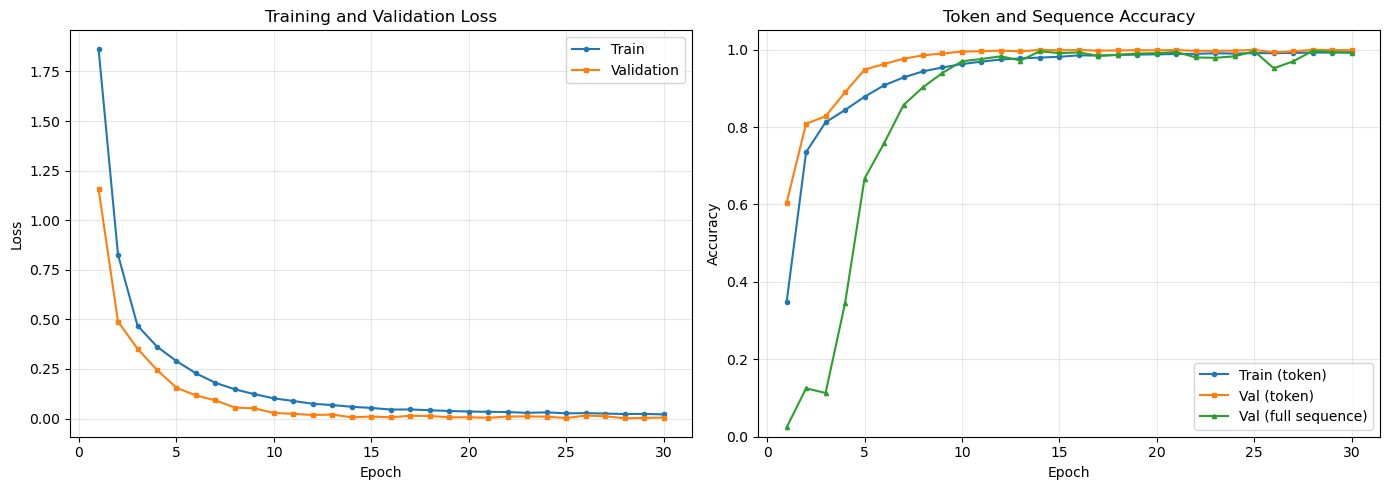

Best validation sequence accuracy: 0.9970


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, EPOCHS+1), train_losses, 'o-', label='Train', markersize=3)
ax1.plot(range(1, EPOCHS+1), val_losses, 's-', label='Validation', markersize=3)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, EPOCHS+1), train_accs, 'o-', label='Train (token)', markersize=3)
ax2.plot(range(1, EPOCHS+1), val_accs, 's-', label='Val (token)', markersize=3)
ax2.plot(range(1, EPOCHS+1), seq_accs, '^-', label='Val (full sequence)', markersize=3)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Token and Sequence Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print(f"Best validation sequence accuracy: {max(seq_accs):.4f}")

## Experiment: Autoregressive Generation

In [13]:
# Test greedy decoding on fresh examples
test_dataset = SortingDataset(n_samples=10, seq_len=SEQ_LEN, max_num=MAX_NUM)

print("Greedy decoding results:")
print("-" * 50)
correct = 0

for i in range(10):
    src, _, tgt_output = test_dataset[i]
    src_nums = (src[:-1] - NUM_OFFSET).tolist()
    expected = (tgt_output[:-1] - NUM_OFFSET).tolist()

    generated = greedy_decode(model, src.unsqueeze(0))

    # Convert generated tokens back to numbers
    gen_nums = [t - NUM_OFFSET for t in generated if t not in (BOS_TOKEN, EOS_TOKEN, PAD_TOKEN)]

    match = gen_nums == expected
    correct += match
    status = "OK" if match else "WRONG"
    print(f"  Input: {src_nums} -> Predicted: {gen_nums} | Expected: {expected} [{status}]")

print(f"\nAutoregressive accuracy: {correct}/10")

Greedy decoding results:
--------------------------------------------------
  Input: [5, 7, 8, 2, 7, 6] -> Predicted: [2, 5, 6, 7, 7, 8] | Expected: [2, 5, 6, 7, 7, 8] [OK]
  Input: [3, 8, 1, 7, 1, 1] -> Predicted: [1, 1, 1, 3, 7, 8] | Expected: [1, 1, 1, 3, 7, 8] [OK]
  Input: [9, 2, 8, 1, 5, 7] -> Predicted: [1, 2, 5, 7, 8, 9] | Expected: [1, 2, 5, 7, 8, 9] [OK]
  Input: [5, 4, 8, 4, 6, 9] -> Predicted: [4, 4, 5, 6, 8, 9] | Expected: [4, 4, 5, 6, 8, 9] [OK]
  Input: [1, 7, 8, 6, 7, 4] -> Predicted: [1, 4, 6, 7, 7, 8] | Expected: [1, 4, 6, 7, 7, 8] [OK]
  Input: [9, 7, 7, 6, 2, 2] -> Predicted: [2, 2, 6, 7, 7, 9] | Expected: [2, 2, 6, 7, 7, 9] [OK]
  Input: [2, 5, 4, 8, 1, 8] -> Predicted: [1, 2, 4, 5, 8, 8] | Expected: [1, 2, 4, 5, 8, 8] [OK]
  Input: [4, 8, 2, 6, 7, 1] -> Predicted: [1, 2, 4, 6, 7, 8] | Expected: [1, 2, 4, 6, 7, 8] [OK]
  Input: [2, 6, 5, 3, 7, 4] -> Predicted: [2, 3, 4, 5, 6, 7] | Expected: [2, 3, 4, 5, 6, 7] [OK]
  Input: [3, 5, 6, 9, 9, 4] -> Predicted: [3, 4, 5,

## Experiment: Cross-Attention Visualization

Inspecting cross-attention weights shows which source tokens the decoder attends to when generating each output token. For sorting, the model should attend to the next-smallest number at each step.

Source: [4, 8, 3, 8, 3, 9]
Generated: [3, 3, 3, 4, 8, 8, 9]


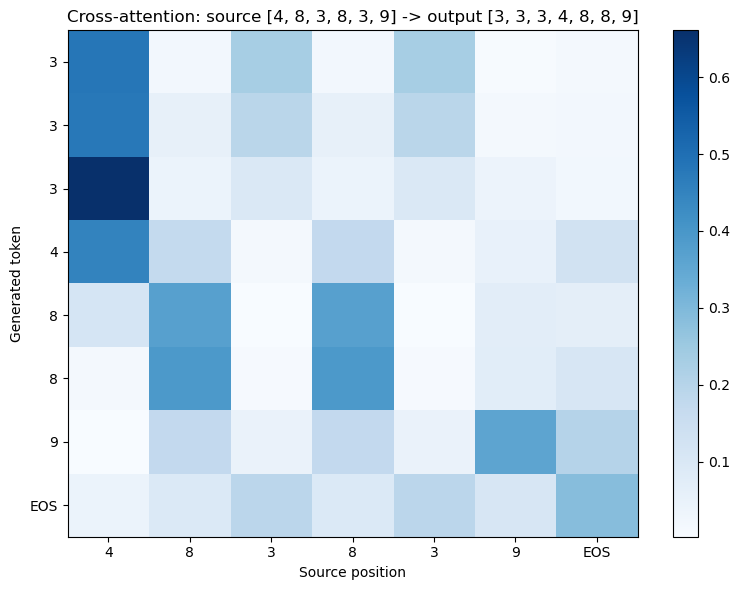

In [14]:
def get_cross_attention_weights(model, src):
    """
    Run greedy decoding and collect cross-attention weights from each decoder layer.
    """
    model.eval()
    src = src.to(device)

    encoder_output = model.encode(src)
    generated = [BOS_TOKEN]
    all_cross_weights = []  # one per generation step

    with torch.no_grad():
        for _ in range(SEQ_LEN + 2):
            tgt = torch.tensor([generated], device=device)
            tgt_mask = generate_causal_mask(len(generated)).to(device)

            # Manual decode to capture cross-attention weights
            x = model.tgt_embedding(tgt) * np.sqrt(model.d_model)
            x = model.pos_encoding(x)

            step_weights = []
            for layer in model.decoder_layers:
                normed = layer.norm1(x)
                self_attn_out, _ = layer.self_attention(normed, normed, normed, tgt_mask)
                x = x + layer.dropout(self_attn_out)

                normed = layer.norm2(x)
                cross_attn_out, cross_weights = layer.cross_attention(
                    normed, encoder_output, encoder_output
                )
                step_weights.append(cross_weights.cpu())
                x = x + layer.dropout(cross_attn_out)

                normed = layer.norm3(x)
                x = x + layer.dropout(layer.feed_forward(normed))

            x = model.decoder_norm(x)
            logits = model.output_proj(x)
            next_token = logits[:, -1, :].argmax(dim=-1).item()

            all_cross_weights.append(step_weights)
            generated.append(next_token)

            if next_token == EOS_TOKEN:
                break

    return generated, all_cross_weights


# Visualize cross-attention for one example
src, _, tgt_output = test_dataset[0]
src_nums = (src[:-1] - NUM_OFFSET).tolist()
generated, cross_weights = get_cross_attention_weights(model, src.unsqueeze(0))
gen_nums = [t - NUM_OFFSET for t in generated if t not in (BOS_TOKEN, EOS_TOKEN, PAD_TOKEN)]

print(f"Source: {src_nums}")
print(f"Generated: {gen_nums}")

# Plot last layer's cross-attention (averaged over heads)
# Collect the final cross-attention weight for each generated token
n_gen = len(generated) - 1  # exclude BOS
src_len = src.size(0)

# Use last layer, average over heads, take last query position from each step
attn_matrix = torch.zeros(n_gen, src_len)
for step in range(n_gen):
    # Last layer's cross-attention, shape: (1, n_heads, current_tgt_len, src_len)
    w = cross_weights[step][-1]  # last layer
    w = w.mean(dim=1)            # average over heads -> (1, tgt_len, src_len)
    attn_matrix[step] = w[0, -1] # last query position

src_labels = [str(n) for n in src_nums] + ['EOS']
tgt_labels = [str(t - NUM_OFFSET) if t >= NUM_OFFSET else {1: 'BOS', 2: 'EOS'}.get(t, str(t))
              for t in generated[1:]]  # exclude initial BOS

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(attn_matrix.numpy(), cmap='Blues', aspect='auto')
ax.set_xticks(range(src_len))
ax.set_xticklabels(src_labels)
ax.set_yticks(range(n_gen))
ax.set_yticklabels(tgt_labels)
ax.set_xlabel('Source position')
ax.set_ylabel('Generated token')
ax.set_title(f'Cross-attention: source {src_nums} -> output {gen_nums}')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Experiment: Generalization to Longer Sequences

The model was trained on sequences of length 6. Test on longer sequences to see if the architecture generalizes. Sinusoidal positional encoding should in principle support arbitrary lengths, but the model may not have learned the pattern well enough.

In [15]:
print("Generalization test:")
print("-" * 60)

for test_len in [4, 6, 8, 10]:
    test_ds = SortingDataset(n_samples=100, seq_len=test_len, max_num=MAX_NUM)
    correct = 0
    for i in range(100):
        src, _, tgt_output = test_ds[i]
        expected = (tgt_output[:-1] - NUM_OFFSET).tolist()
        generated = greedy_decode(model, src.unsqueeze(0), max_len=test_len + 5)
        gen_nums = [t - NUM_OFFSET for t in generated if t not in (BOS_TOKEN, EOS_TOKEN, PAD_TOKEN)]
        if gen_nums == expected:
            correct += 1
    print(f"  Length {test_len:>2}: {correct}/100 correct")

Generalization test:
------------------------------------------------------------
  Length  4: 0/100 correct
  Length  6: 100/100 correct
  Length  8: 8/100 correct
  Length 10: 0/100 correct


## Connections

- The decoder block is the core of GPT-style models (decoder-only, no cross-attention, just masked self-attention + FFN)
- The full encoder-decoder architecture is used in T5, BART, and the original Transformer for machine translation
- Cross-attention is also used in vision-language models (e.g., Flamingo) where visual features are the "encoder output" and text is the decoder
- Greedy decoding is the simplest generation strategy. Beam search, nucleus sampling (top-p), and temperature scaling are alternatives that trade off quality vs diversity
- The sorting task demonstrates that the model learns to use cross-attention to "point" at source tokens in order, a simplified version of the pointer mechanism used in some seq2seq models

## Key Equations

Pre-LN Decoder Block (three sub-layers):
$$x = x + \text{MaskedMHA}(\text{LN}(x))$$
$$x = x + \text{CrossMHA}(\text{LN}(x), \text{enc\_out})$$
$$x = x + \text{FFN}(\text{LN}(x))$$

Causal mask:
$$M_{ij} = \begin{cases} 1 & j \leq i \\ 0 & j > i \end{cases}$$

Cross-attention: $Q$ from decoder, $K$ and $V$ from encoder.

Autoregressive generation:
$$P(y_t | y_1, \ldots, y_{t-1}, X) = \text{softmax}(W_{\text{vocab}} \cdot \text{Decoder}(y_{<t}, \text{Encoder}(X)))$$